In [1]:
import sys
from pathlib import Path
_r = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts' / 'config.py').exists())
sys.path.insert(0, str(_r / 'scripts'))
from notebook_init import setup
cfg, PATHS, POPULATIONS, HARD_FILTERS, SITUATIONAL_FILTERS, ML = setup()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import combinations

DIR_A  = PATHS.ML_MODELS_STAT   # statistical_v1/05a_stat_only_training
DIR_B  = PATHS.ML_MODELS_FST    # fst/05b_fst_only_training
DIR_C  = PATHS.ML_MODELS_BOTH   # statistical_v1/05c_fst_and_stat_training
print('05a:', DIR_A)
print('05b:', DIR_B)
print('05c:', DIR_C)


Project root : /home/ibmelab/Projects/AISNP_Research
genomes_data : /mnt/data/aisnp_data/1000genomes/
output root  : output
05a: /mnt/data/aisnp_data/1000genomes/outputs/statistical_only/05a_stat_only_training
05b: /mnt/data/aisnp_data/1000genomes/outputs/05b_fst_only_training
05c: /mnt/data/aisnp_data/1000genomes/outputs/05c_fst_and_stat_training


## 1. Top-50 SNPs per Approach

In [2]:
def load_top50(csv_path, feature_col='feature', n=50):
    df = pd.read_csv(csv_path)
    col = feature_col if feature_col in df.columns else df.columns[0]
    return set(df[col].head(n).tolist())

# 05a — stat-only (RF importance from consensus SNPs)
snps_a = load_top50(DIR_A / 'consensus_snps_importance.csv')

# 05b — FST-only (RF importance)
snps_b = load_top50(DIR_B / 'feature_importances.csv')

# 05c — FST+stat, RF and LR separately
snps_c_rf = load_top50(DIR_C / 'rf_feature_importances.csv')
snps_c_lr = load_top50(DIR_C / 'lr_feature_importances.csv')
snps_c    = snps_c_rf | snps_c_lr   # union of both rankings

print(f'05a (stat-only)   : {len(snps_a)} SNPs')
print(f'05b (FST-only)    : {len(snps_b)} SNPs')
print(f'05c RF            : {len(snps_c_rf)} SNPs')
print(f'05c LR            : {len(snps_c_lr)} SNPs')
print(f'05c combined      : {len(snps_c)} SNPs')


05a (stat-only)   : 50 SNPs
05b (FST-only)    : 50 SNPs
05c RF            : 50 SNPs
05c LR            : 50 SNPs
05c combined      : 86 SNPs


## 2. Pairwise SNP Overlap

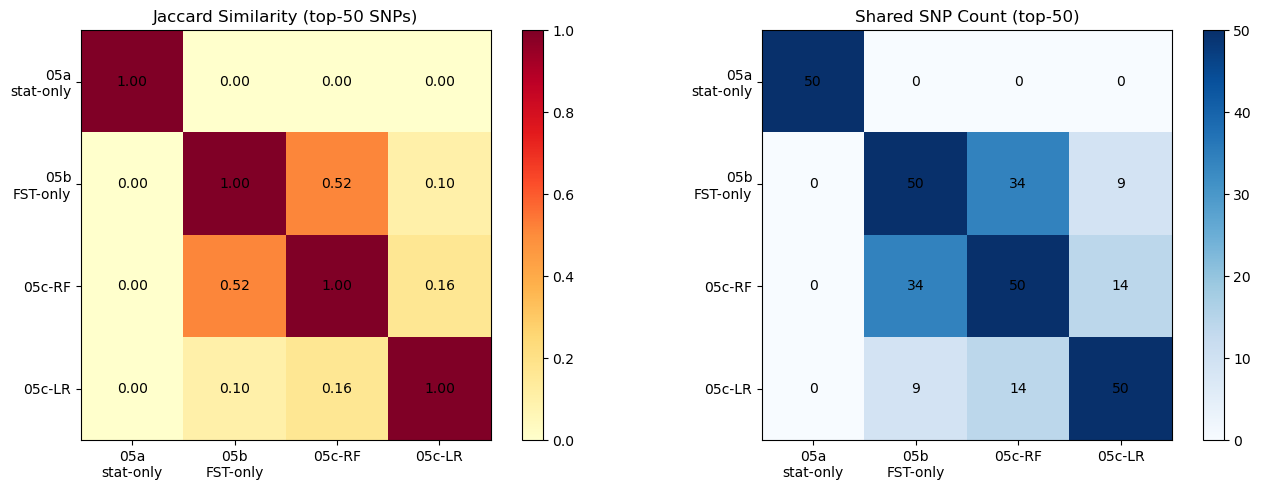

In [3]:
sets = {
    '05a\nstat-only': snps_a,
    '05b\nFST-only':  snps_b,
    '05c-RF':         snps_c_rf,
    '05c-LR':         snps_c_lr,
}
labels = list(sets.keys())

# Jaccard similarity matrix
n = len(labels)
jaccard = np.zeros((n, n))
overlap_count = np.zeros((n, n), dtype=int)
for i, (la, sa) in enumerate(sets.items()):
    for j, (lb, sb) in enumerate(sets.items()):
        inter = len(sa & sb)
        union = len(sa | sb)
        jaccard[i, j] = inter / union if union else 0
        overlap_count[i, j] = inter

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Jaccard heatmap
ax = axes[0]
im = ax.imshow(jaccard, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(labels, fontsize=10)
ax.set_yticks(range(n)); ax.set_yticklabels(labels, fontsize=10)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{jaccard[i,j]:.2f}', ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax)
ax.set_title('Jaccard Similarity (top-50 SNPs)')

# Shared count heatmap
ax = axes[1]
im2 = ax.imshow(overlap_count, cmap='Blues', vmin=0, vmax=50)
ax.set_xticks(range(n)); ax.set_xticklabels(labels, fontsize=10)
ax.set_yticks(range(n)); ax.set_yticklabels(labels, fontsize=10)
for i in range(n):
    for j in range(n):
        ax.text(j, i, str(overlap_count[i,j]), ha='center', va='center', fontsize=10)
plt.colorbar(im2, ax=ax)
ax.set_title('Shared SNP Count (top-50)')

plt.tight_layout()
plt.show()


## 3. SNP Set Membership

In [4]:
all_snps = snps_a | snps_b | snps_c_rf | snps_c_lr
rows = []
for snp in sorted(all_snps):
    rows.append({
        'snp_id':  snp,
        'in_05a':  snp in snps_a,
        'in_05b':  snp in snps_b,
        'in_05c_rf': snp in snps_c_rf,
        'in_05c_lr': snp in snps_c_lr,
    })
membership = pd.DataFrame(rows)
membership['n_approaches'] = membership[['in_05a','in_05b','in_05c_rf','in_05c_lr']].sum(axis=1)

print('SNPs by number of approaches they appear in:')
print(membership['n_approaches'].value_counts().sort_index().to_frame('count'))

print(f'\nIn all 4 rankings:')
display(membership[membership['n_approaches'] == 4][['snp_id']].reset_index(drop=True))

print(f'\nIn all 3 main approaches (05a + 05b + either 05c):')
core = membership[(membership.in_05a) & (membership.in_05b) &
                   (membership.in_05c_rf | membership.in_05c_lr)]
display(core[['snp_id','in_05a','in_05b','in_05c_rf','in_05c_lr']].reset_index(drop=True))


SNPs by number of approaches they appear in:
              count
n_approaches       
1               104
2                39
3                 6

In all 4 rankings:


,snp_id



In all 3 main approaches (05a + 05b + either 05c):


,snp_id,in_05a,in_05b,in_05c_rf,in_05c_lr


## 4. Unique vs Shared SNP Distribution

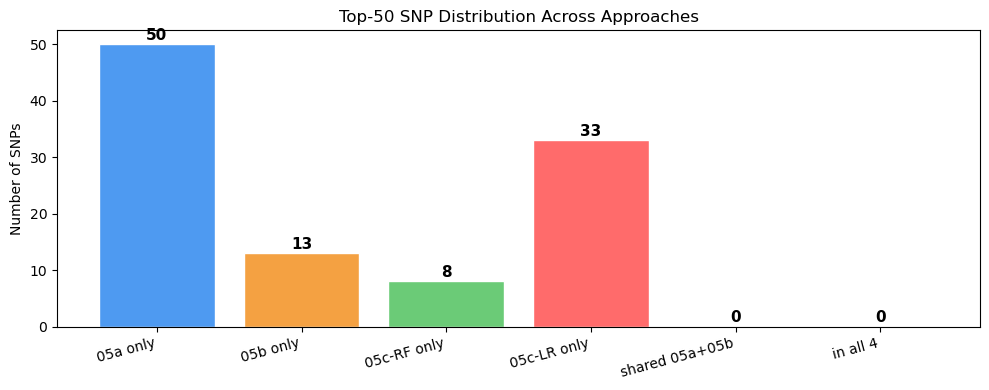

In [5]:
unique_a  = snps_a  - snps_b - snps_c_rf - snps_c_lr
unique_b  = snps_b  - snps_a - snps_c_rf - snps_c_lr
unique_cf = snps_c_rf - snps_a - snps_b - snps_c_lr
unique_cl = snps_c_lr - snps_a - snps_b - snps_c_rf
shared_all= snps_a & snps_b & snps_c_rf & snps_c_lr
shared_ab = (snps_a & snps_b) - snps_c_rf - snps_c_lr

summary = pd.DataFrame({
    'approach': ['05a only','05b only','05c-RF only','05c-LR only','shared 05a+05b','in all 4'],
    'count':    [len(unique_a), len(unique_b), len(unique_cf), len(unique_cl), len(shared_ab), len(shared_all)]
})

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#4e9af1','#f4a142','#6bcb77','#ff6b6b','#9b59b6','#2c3e50']
bars = ax.bar(summary['approach'], summary['count'], color=colors, edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of SNPs')
ax.set_title('Top-50 SNP Distribution Across Approaches')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


## 5. Performance Comparison

In [6]:
def load_perf(path, approach_label):
    """Load model comparison CSV and tag with approach label."""
    df = pd.read_csv(path)
    df['approach'] = approach_label
    # Normalise column names to 'model' and 'accuracy'
    df.columns = [c.lower().replace(' ','_') for c in df.columns]
    return df

perf_a = load_perf(DIR_A / 'consensus_snps_cv_results.csv',  '05a stat-only')
perf_b = load_perf(DIR_B / 'model_comparison.csv',           '05b FST-only')
perf_c = load_perf(DIR_C / 'statistical_ml_results.csv',     '05c FST+stat')

# Print raw to see column shapes
for name, df in [('05a', perf_a), ('05b', perf_b), ('05c', perf_c)]:
    print(f'{name}: {list(df.columns)}')
    display(df)


05a: ['model', 'accuracy_mean', 'accuracy_std', 'f1_mean', 'f1_std', 'precision_mean', 'recall_mean', 'train_accuracy', 'overfit_gap', 'approach']


,model,accuracy_mean,accuracy_std,f1_mean,f1_std,precision_mean,recall_mean,train_accuracy,overfit_gap,approach
0,Naive Bayes,0.902812,0.024461,0.901025,0.025126,0.919245,0.902812,0.912702,0.009890,05a stat-only
1,SVM (RBF),0.902693,0.030674,0.902244,0.031355,0.906312,0.902693,0.934533,0.031840,05a stat-only
2,Logistic Regression,0.898851,0.022774,0.899122,0.022648,0.903933,0.898851,0.954363,0.055512,05a stat-only
3,SVM (Linear),0.898851,0.034427,0.899056,0.034269,0.902241,0.898851,0.953869,0.055018,05a stat-only
4,XGBoost,0.877030,0.036708,0.877037,0.037430,0.884899,0.877030,0.946924,0.069894,05a stat-only
5,MLP Neural Network,0.857208,0.034995,0.856630,0.035926,0.864736,0.857208,0.888383,0.031175,05a stat-only
6,Gradient Boosting,0.843307,0.026599,0.842861,0.028271,0.852778,0.843307,0.971723,0.128416,05a stat-only
7,Random Forest,0.841168,0.032579,0.834922,0.037705,0.874580,0.841168,0.859128,0.017960,05a stat-only
8,AdaBoost,0.738059,0.040135,0.733036,0.044098,0.789167,0.738059,0.827376,0.089317,05a stat-only
9,K-Nearest Neighbors,0.640931,0.022039,0.595967,0.029470,0.689647,0.640931,0.713785,0.072855,05a stat-only


05b: ['model', 'accuracy', 'accuracy_std', 'best_n_features', 'approach']


,model,accuracy,accuracy_std,best_n_features,approach
0,Logistic Regression,0.948436,0.014487,45,05b FST-only
1,SVM (RBF),0.948416,0.017024,50,05b FST-only
2,Random Forest,0.928594,0.009557,45,05b FST-only
3,XGBoost,0.922554,0.019560,50,05b FST-only
4,Gradient Boosting,0.910653,0.019164,50,05b FST-only


05c: ['model', 'accuracy', 'approach']


,model,accuracy,approach
0,Random Forest,0.960396,05c FST+stat
1,XGBoost,0.930693,05c FST+stat
2,Logistic Regression,0.980198,05c FST+stat


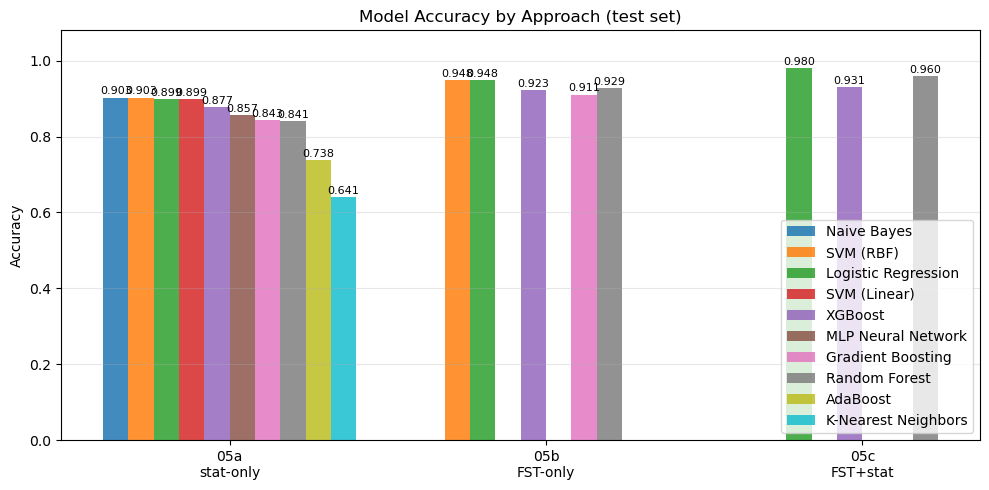

In [7]:
# Normalise to (approach, model, accuracy) and plot
def extract_acc(df, approach):
    cols = df.columns.tolist()
    # find model col and accuracy col
    model_col = next((c for c in cols if 'model' in c), cols[0])
    acc_col   = next((c for c in cols if 'acc' in c), cols[1])
    return pd.DataFrame({'model': df[model_col], 'accuracy': df[acc_col], 'approach': approach})

combined = pd.concat([
    extract_acc(perf_a, '05a\nstat-only'),
    extract_acc(perf_b, '05b\nFST-only'),
    extract_acc(perf_c, '05c\nFST+stat'),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 5))
models = combined['model'].unique()
approaches = combined['approach'].unique()
x = np.arange(len(approaches))
width = 0.8 / len(models)
palette = plt.cm.tab10.colors

for k, model in enumerate(models):
    vals = [combined[(combined['approach']==ap) & (combined['model']==model)]['accuracy']
            .values[0] if len(combined[(combined['approach']==ap) & (combined['model']==model)]) else np.nan
            for ap in approaches]
    offset = (k - len(models)/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=model, color=palette[k], alpha=0.85)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(approaches)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.08)
ax.set_title('Model Accuracy by Approach (test set)')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Performance vs Feature Count

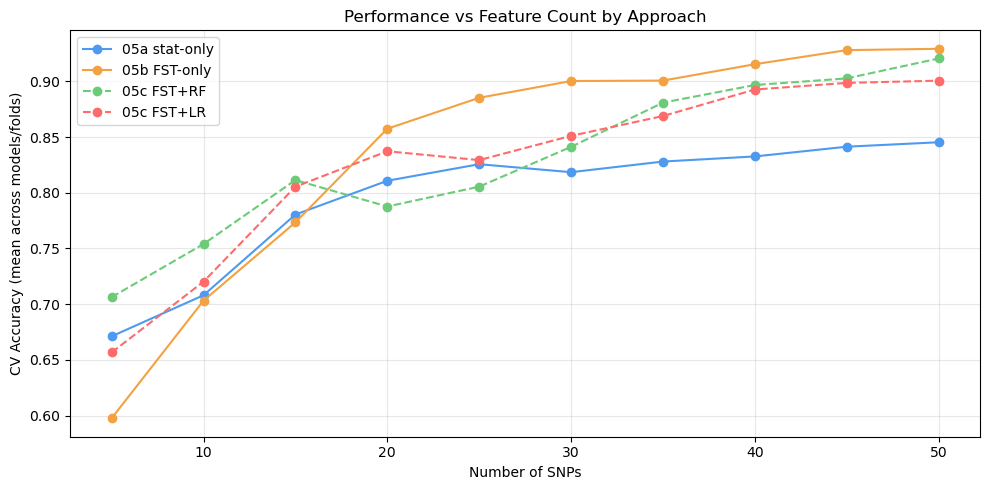

In [8]:
def load_sweep(path, acc_col_hint='acc'):
    df = pd.read_csv(path)
    df.columns = [c.lower() for c in df.columns]
    n_col  = next(c for c in df.columns if 'snp' in c or 'n_' in c or 'feat' in c)
    ac_col = next(c for c in df.columns if acc_col_hint in c)
    # Aggregate — multiple rows per n_snps (e.g. per model or per fold) → take mean
    return (df[[n_col, ac_col]]
            .rename(columns={n_col: 'n_snps', ac_col: 'accuracy'})
            .groupby('n_snps', as_index=False)
            .mean()
            .sort_values('n_snps'))

sw_a  = load_sweep(DIR_A / 'consensus_snps_reduced_results.csv')
sw_b  = load_sweep(DIR_B / 'feature_size_results.csv')
sw_cR = load_sweep(DIR_C / 'rf_feature_size_results.csv')
sw_cL = load_sweep(DIR_C / 'lr_feature_size_results.csv')

fig, ax = plt.subplots(figsize=(10, 5))
for label, sw, color, ls in [
    ('05a stat-only', sw_a,  '#4e9af1', '-'),
    ('05b FST-only',  sw_b,  '#f4a142', '-'),
    ('05c FST+RF',    sw_cR, '#6bcb77', '--'),
    ('05c FST+LR',    sw_cL, '#ff6b6b', '--'),
]:
    ax.plot(sw['n_snps'], sw['accuracy'], marker='o', label=label, color=color, linestyle=ls)

ax.set_xlabel('Number of SNPs')
ax.set_ylabel('CV Accuracy (mean across models/folds)')
ax.set_title('Performance vs Feature Count by Approach')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Summary

In [9]:
print('='*70)
print('SELF-EVALUATION SUMMARY')
print('='*70)
print(f'\nSNP overlap (top-50):')
print(f'  05a ∩ 05b           : {len(snps_a & snps_b)}')
print(f'  05a ∩ 05c (either)  : {len(snps_a & snps_c)}')
print(f'  05b ∩ 05c (either)  : {len(snps_b & snps_c)}')
print(f'  All 3 approaches    : {len(snps_a & snps_b & snps_c)}')
print(f'  Unique to 05a       : {len(unique_a)}')
print(f'  Unique to 05b       : {len(unique_b)}')
print(f'  Unique to 05c       : {len(snps_c - snps_a - snps_b)}')
print('='*70)


SELF-EVALUATION SUMMARY

SNP overlap (top-50):
  05a ∩ 05b           : 0
  05a ∩ 05c (either)  : 0
  05b ∩ 05c (either)  : 37
  All 3 approaches    : 0
  Unique to 05a       : 50
  Unique to 05b       : 13
  Unique to 05c       : 49
